# Lab 3 — Tiny RSSM: Recurrent State-Space Model

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/overdued/world-model-spatial-intelligence-course/blob/main/labs/lab03_tiny_rssm/notebook_en.ipynb)

**World Models & Spatial Intelligence · Hands-on Lab 3**

In Lab 2 we trained a deterministic Encoder → Dynamics → Decoder and watched open-loop rollouts drift. That model has a deeper flaw: given a history, it can only predict **one** future. The real world (including our little ball, now with random perturbations) is **stochastic**: the same history can lead to several equally plausible futures. A model that must give a "single answer" for a stochastic future can only output the **average** of all possible futures, which is a blurry ghost.

This lab implements the core architecture behind PlaNet and Dreamer, the **RSSM (Recurrent State-Space Model)**, which splits the latent state into two halves:

```
deterministic path:  h_t = GRU(h_{t-1}, z_{t-1}, a_{t-1})     ← memory, handles long-range dependencies
stochastic path:     z_t ~ prior p(z_t | h_t)                  ← uncertainty, handles multi-modal futures
inference:           z_t ~ posterior q(z_t | h_t, x_t)        ← correction after seeing the observation
generation:          x̂_t = Decoder(h_t, z_t)
```

All the core logic (GRU cell, Gaussian prior/posterior, reparameterization, closed-form KL) is a few dozen lines of PyTorch visible in this notebook. No black boxes.

## 1. Motivation — three questions

The Kalman filter in Lab 1 already gave us the pattern: **predict** (extrapolate the dynamics, uncertainty grows) + **update** (correct with the observation, uncertainty shrinks). Lab 2's deterministic model only has the predict half, and it cannot say "I'm not sure". The RSSM is the large-scale learned version of this pattern: the prior + GRU do the predict step, the posterior does the update step.

This lab answers three questions with experiments:

1. **Why is a purely deterministic RNN not enough?** → Section 8 trains a deterministic-only baseline with exactly the same structure and shows it degrades into a blurry average on stochastic futures.
2. **Why do we need a stochastic latent state?** → Section 3 first shows the environment itself has "one history, many futures"; Section 7 shows the RSSM can sample several futures that are **each sharp**.
3. **Why train with the posterior but imagine with the prior?** → Section 5 (where the training signal comes from) and Section 7 (no observations are available during imagination) answer this; the KL term keeps the two aligned.

## 2. Setup

**Why:** The only heavy dependency is PyTorch (the CPU build is enough, and Colab has it preinstalled). `imageio` saves the imagination rollouts as GIFs. The first cell detects Colab and installs anything missing; every experiment finishes on CPU within a few minutes.

In [1]:
# @title setup
import sys, subprocess

IN_COLAB = "google.colab" in sys.modules

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for pkg, name in [("torch", "torch"), ("imageio", "imageio"), ("matplotlib", "matplotlib")]:
    ensure(pkg, name)

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import imageio.v2 as imageio

%matplotlib inline
os.makedirs("assets", exist_ok=True)
torch.manual_seed(0)
np.random.seed(0)
print("torch", torch.__version__, "| device: cpu | colab:", IN_COLAB)


torch 2.14.0+cu130 | device: cpu | colab: False


## 3. Environment & Dataset: a stochastic Moving Ball

**Why:** We reuse the ball physics from Labs 0/2 (force action, friction, wall bounce) with one key change: **the velocity receives a random perturbation at every step** (think of a random gust of wind). So even with exactly the same history and action sequence, the future trajectory is no longer unique. That is exactly what the stochastic latent is meant to model.

The data is generated in code, no download needed: 300 episodes × 20 steps, 64×64 grayscale frames + a 2-D force action.

frames: torch.Size([300, 20, 1, 64, 64])  actions: torch.Size([300, 20, 2])


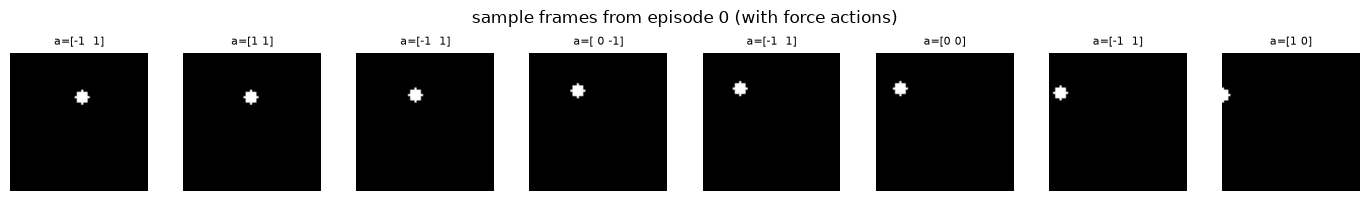

In [2]:
SIZE, N_EP, EP_LEN = 64, 300, 20        # frame size / #episodes / steps per episode
DT, FRICTION, BOUNCE, FORCE = 0.1, 0.95, 0.9, 2.0
NOISE_STD = 0.1                         # per-step random velocity perturbation: the environment's intrinsic stochasticity

def render_ball(x, y, size=SIZE):
    img = np.zeros((size, size), dtype=np.float32)
    px = int(np.clip(x, 0, 1) * (size - 1))
    py = int(np.clip(y, 0, 1) * (size - 1))
    yy, xx = np.mgrid[0:size, 0:size]
    img[(xx - px) ** 2 + (yy - py) ** 2 <= 3 ** 2] = 1.0
    return img

def step_world(state, a, rng):
    """one physics step; the random velocity kick makes the world stochastic"""
    x, y, vx, vy = state
    vx = (vx + FORCE * a[0] * DT) * FRICTION + rng.normal(0, NOISE_STD)
    vy = (vy + FORCE * a[1] * DT) * FRICTION + rng.normal(0, NOISE_STD)
    x, y = x + vx * DT, y + vy * DT
    if x < 0: x, vx = -x, -vx * BOUNCE
    if x > 1: x, vx = 2 - x, -vx * BOUNCE
    if y < 0: y, vy = -y, -vy * BOUNCE
    if y > 1: y, vy = 2 - y, -vy * BOUNCE
    return (x, y, vx, vy)

def simulate_episode(rng, ep_len=EP_LEN):
    state = (*rng.uniform(0.15, 0.85, 2), *rng.uniform(-0.5, 0.5, 2))
    frames, actions = [], []
    for t in range(ep_len):
        a = rng.integers(-1, 2, 2).astype(np.float32)
        state = step_world(state, a, rng)
        frames.append(render_ball(state[0], state[1]))
        actions.append(a)
    return np.stack(frames), np.stack(actions)

rng = np.random.default_rng(0)
episodes = [simulate_episode(rng) for _ in range(N_EP)]
frames_np = np.stack([e[0] for e in episodes])            # (N_EP, EP_LEN, 64, 64)
actions_np = np.stack([e[1] for e in episodes])           # (N_EP, EP_LEN, 2)
frames_t = torch.from_numpy(frames_np).unsqueeze(2)       # (N_EP, T, 1, 64, 64)
actions_t = torch.from_numpy(actions_np)                  # (N_EP, T, 2)
print(f"frames: {frames_t.shape}  actions: {actions_t.shape}")

fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(frames_np[0, i], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"a={actions_np[0, i].astype(int)}", fontsize=8)
    ax.axis("off")
plt.suptitle("sample frames from episode 0 (with force actions)")
plt.tight_layout()
plt.show()


### 3.1 One history, many futures

Before explaining the model, let's confirm that **the world itself** is stochastic: start from exactly the same state, apply exactly the same action sequence, and simulate twice with different random seeds. If the future were unique, the two trajectories would coincide; if they clearly diverge, then no model that "predicts one future" can get both cases right. The optimum of an MSE/BCE loss for such a model is the **average** of the futures. This is the root cause of the blurry baseline in Section 8.

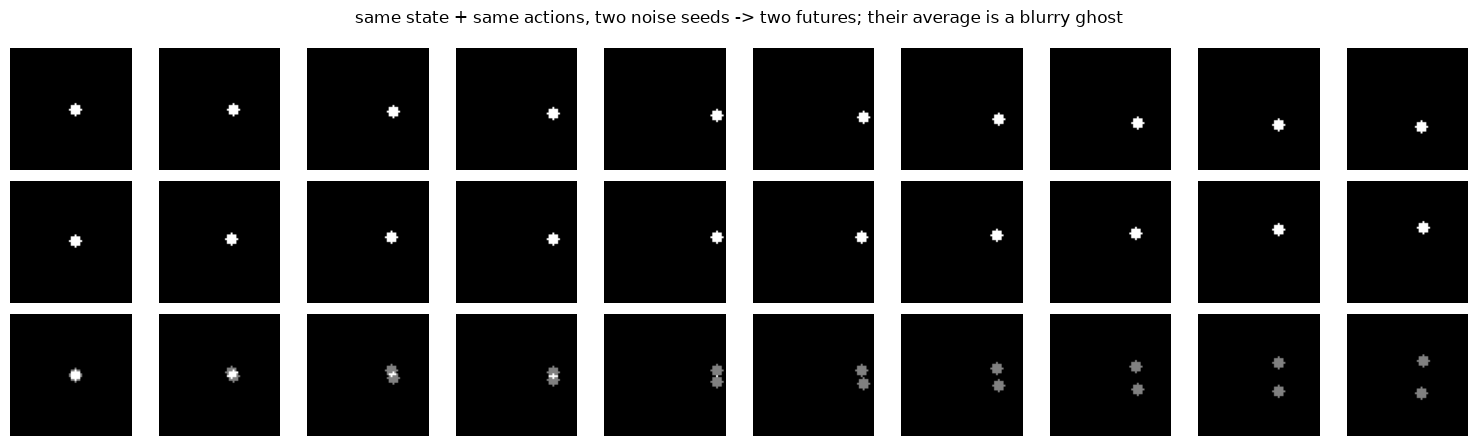

In [3]:
def continue_rollout(state, action_seq, seed):
    """same state, same actions, different noise -> a different future"""
    r = np.random.default_rng(seed)
    frames = []
    for a in action_seq:
        state = step_world(state, a, r)
        frames.append(render_ball(state[0], state[1]))
    return frames

state0 = (0.5, 0.5, 0.3, 0.1)
same_actions = [np.array([1, 0], dtype=np.float32)] * 10
future_A = continue_rollout(state0, same_actions, seed=1)
future_B = continue_rollout(state0, same_actions, seed=2)
average = [(a + b) / 2 for a, b in zip(future_A, future_B)]

fig, axes = plt.subplots(3, 10, figsize=(15, 4.5))
for j in range(10):
    axes[0, j].imshow(future_A[j], cmap="gray", vmin=0, vmax=1)
    axes[1, j].imshow(future_B[j], cmap="gray", vmin=0, vmax=1)
    axes[2, j].imshow(average[j], cmap="gray", vmin=0, vmax=1)
    for ax in axes[:, j]:
        ax.axis("off")
axes[0, 0].set_ylabel("future A", fontsize=10)
axes[1, 0].set_ylabel("future B", fontsize=10)
axes[2, 0].set_ylabel("average", fontsize=10)
plt.suptitle("same state + same actions, two noise seeds -> two futures; their average is a blurry ghost")
plt.tight_layout()
plt.show()


## 4. Build the Model: Tiny RSSM

**Why this architecture:** Each time step carries two states:

- **Deterministic state $h_t$** (the GRU hidden state): remembers history losslessly and handles long-range dependencies; $h_t = \mathrm{GRU}([z_{t-1}, a_{t-1}],\, h_{t-1})$.
- **Stochastic state $z_t$**: sampled from a diagonal Gaussian; it carries "how the environment might randomly behave at this step". 16 dimensions.

Around them sit three learnable distributions/maps, each written out explicitly in a few lines of PyTorch:

| Component | Formula | Implementation |
|---|---|---|
| Encoder | $e_t = \mathrm{enc}(x_t)$ | 3 strided conv layers → 128-d embedding |
| Prior | $p_\theta(z_t \mid h_t) = \mathcal{N}(\mu_p(h_t), \sigma_p(h_t))$ | MLP, does **not** see the current observation |
| Posterior | $q_\theta(z_t \mid h_t, x_t) = \mathcal{N}(\mu_q(h_t, e_t), \sigma_q(h_t, e_t))$ | MLP, **does** see the current observation |
| Decoder | $\hat{x}_t = \mathrm{dec}(h_t, z_t)$ | mirrored transposed convs, outputs logits |

Two key details are also implemented explicitly: the **reparameterization trick** ($z = \mu + \sigma \odot \epsilon$; the noise is independent of the parameters, so gradients flow through $\mu, \sigma$ as usual) and the **closed-form KL** (the KL between two diagonal Gaussians has an analytic solution, so no sampling estimate is needed). With `stochastic=False` the same class degrades into a deterministic baseline ($z$ is the mean and the KL is replaced by an MSE); Section 8 uses it as the control.

In [4]:
Z_DIM, H_DIM, E_DIM, A_DIM = 16, 64, 128, 2

class Encoder(nn.Module):
    """image x_t (1,64,64) -> embedding e_t (128)"""
    def __init__(self, e_dim=E_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 4, 2, 1), nn.ReLU(),    # 64 -> 32
            nn.Conv2d(16, 32, 4, 2, 1), nn.ReLU(),   # 32 -> 16
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),   # 16 -> 8
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, e_dim), nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

class Decoder(nn.Module):
    """(h_t, z_t) -> image logits (1,64,64); sigmoid is only used for display"""
    def __init__(self, in_dim=H_DIM + Z_DIM):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(in_dim, 128), nn.ReLU(),
                                nn.Linear(128, 64 * 8 * 8), nn.ReLU())
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),   # 8 -> 16
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.ReLU(),   # 16 -> 32
            nn.ConvTranspose2d(16, 1, 4, 2, 1),               # 32 -> 64, raw logits
        )

    def forward(self, h, z):
        return self.deconv(self.fc(torch.cat([h, z], -1)).view(-1, 64, 8, 8))

def gaussian_stats(raw, min_std=0.1):
    """MLP output -> (mu, std); softplus + min_std keep std positive and away from 0"""
    mu, raw_std = raw.chunk(2, dim=-1)
    return mu, F.softplus(raw_std) + min_std

def sample_gaussian(mu, std):
    """reparameterization trick: z = mu + std * eps, eps ~ N(0, I) is independent of the parameters"""
    return mu + std * torch.randn_like(std)

def kl_gaussian(mu_q, std_q, mu_p, std_p):
    """closed-form KL( N(mu_q,std_q^2) || N(mu_p,std_p^2) ), summed over latent dims, averaged over the batch"""
    var_q, var_p = std_q ** 2, std_p ** 2
    kl = torch.log(std_p / std_q) + (var_q + (mu_q - mu_p) ** 2) / (2 * var_p) - 0.5
    return kl.sum(-1).mean()

class TinyRSSM(nn.Module):
    def __init__(self, z_dim=Z_DIM, h_dim=H_DIM, stochastic=True):
        super().__init__()
        self.stochastic, self.z_dim, self.h_dim = stochastic, z_dim, h_dim
        self.enc = Encoder()
        self.gru = nn.GRUCell(z_dim + A_DIM, h_dim)                 # h_t = GRU([z,a], h)
        self.prior_net = nn.Sequential(nn.Linear(h_dim, 128), nn.ReLU(),
                                       nn.Linear(128, 2 * z_dim))   # p(z_t|h_t): does not see x_t
        self.post_net = nn.Sequential(nn.Linear(h_dim + E_DIM, 128), nn.ReLU(),
                                      nn.Linear(128, 2 * z_dim))    # q(z_t|h_t,x_t): sees x_t
        self.dec = Decoder(h_dim + z_dim)

    def prior(self, h):
        return gaussian_stats(self.prior_net(h))

    def posterior(self, h, e):
        return gaussian_stats(self.post_net(torch.cat([h, e], -1)))

    def observe(self, xs, acts):
        """teacher-forced forward pass: the posterior sees the real frame at every step. Returns (recon, kl, stats, recon_frames)"""
        B, T = xs.shape[:2]
        h = xs.new_zeros(B, self.h_dim); z = xs.new_zeros(B, self.z_dim)
        a_prev = xs.new_zeros(B, A_DIM)
        rec, kl, stats, recons = 0.0, 0.0, [], []
        for t in range(T):
            h = self.gru(torch.cat([z, a_prev], -1), h)             # 1) advance the deterministic path
            mu_p, std_p = self.prior(h)                             # 2) prior: blind guess of z_t
            mu_q, std_q = self.posterior(h, self.enc(xs[:, t]))     # 3) posterior: correct using x_t
            if self.stochastic:
                z = sample_gaussian(mu_q, std_q)                    # 4) reparameterized sample
                kl = kl + kl_gaussian(mu_q, std_q, mu_p, std_p)     #    closed-form KL
            else:  # deterministic baseline: z is a point estimate; train the prior with MSE instead of KL
                z = mu_q
                kl = kl + F.mse_loss(mu_p, mu_q.detach())
            logits = self.dec(h, z)                                 # 5) generate x̂_t
            rec = rec + F.binary_cross_entropy_with_logits(
                logits, xs[:, t], pos_weight=POS_W, reduction="sum") / B  # sum over pixels (the true ELBO), mean over the batch
            a_prev = acts[:, t]
            stats.append((mu_p.detach(), std_p.detach(), mu_q.detach(), std_q.detach()))
            recons.append(torch.sigmoid(logits.detach())[:, 0])
        return rec / T, kl / T, stats, torch.stack(recons, 1)

    @torch.no_grad()
    def imagine(self, x_ctx, a_ctx, a_fut):
        """burn-in digests the history frames with the posterior, then imagines the future open-loop with the prior only"""
        B, Tc = x_ctx.shape[:2]
        h = x_ctx.new_zeros(B, self.h_dim); z = x_ctx.new_zeros(B, self.z_dim)
        a_prev = x_ctx.new_zeros(B, A_DIM)
        for t in range(Tc):                                         # burn-in: sees observations
            h = self.gru(torch.cat([z, a_prev], -1), h)
            mu_q, std_q = self.posterior(h, self.enc(x_ctx[:, t]))
            z = sample_gaussian(mu_q, std_q) if self.stochastic else mu_q
            a_prev = a_ctx[:, t]
        frames = []
        for k in range(a_fut.shape[1]):                             # imagination: no observations
            h = self.gru(torch.cat([z, a_fut[:, k]], -1), h)
            mu_p, std_p = self.prior(h)
            z = sample_gaussian(mu_p, std_p) if self.stochastic else mu_p
            frames.append(torch.sigmoid(self.dec(h, z))[:, 0])
        return torch.stack(frames, 1)                               # (B, T_fut, 64, 64)

POS_W = torch.tensor(10.0)   # the ball covers only ~0.7% of pixels; weight positives to avoid an "all black" collapse (as in Lab 2)
rssm = TinyRSSM(stochastic=True)
print(f"parameters: {sum(p.numel() for p in rssm.parameters()):,}  (tiny — CPU-friendly)")


parameters: 1,203,169  (tiny — CPU-friendly)


## 5. Train: ELBO = Reconstruction + β · KL

**Why these two terms:** This is the ELBO (evidence lower bound) of a sequential VAE:

$$\mathcal{L} = \underbrace{\sum_t \mathrm{BCE}(\hat{x}_t, x_t)}_{\text{reconstruction: rebuild every frame}} + \beta \underbrace{\sum_t \mathrm{KL}\big(q(z_t|h_t,x_t)\,\|\,p(z_t|h_t)\big)}_{\text{KL: posterior may not stray too far from prior}}$$

**Why train with the posterior?** The reconstruction loss needs a $z_t$ that "knows the answer": the posterior has seen $x_t$, so it can give the decoder a latent precise enough to reconstruct, and gradients can flow back into the encoder/decoder/GRU. **Then why not let the posterior use the observation freely?** Because during imagination (next section) there is no $x_t$ to look at, only the prior. If the posterior carries information the prior can never guess, the model never learns to "walk blind". The KL term is the bridge that aligns the two: it penalizes "information you only have after seeing the answer" and forces the prior to learn to predict the posterior. $\beta=1$ is the standard ELBO; if $\beta$ is too small the prior learns nothing, and if it is too large the posterior stops using the observation (posterior collapse). Exercise 2 lets you see this trade-off first-hand.

**An easy pitfall (we fell into it ourselves):** BCE defaults to a `mean` over pixels, so the reconstruction term is only ~0.05–0.7, while the KL is **summed** over latent dimensions in nats (~1–20). That scale mismatch makes any $\beta \geq 0.1$ crush the posterior (collapse). The true ELBO is a log-likelihood **summed** over pixels; this notebook uses `reduction="sum"` to keep that ratio, and $\beta=1$ trains stably.

step  150/500  recon(sum-BCE) 999.5  KL 0.16


step  300/500  recon(sum-BCE) 1012.1  KL 0.32


step  450/500  recon(sum-BCE) 81.7  KL 19.60


trained in 930.0s on CPU


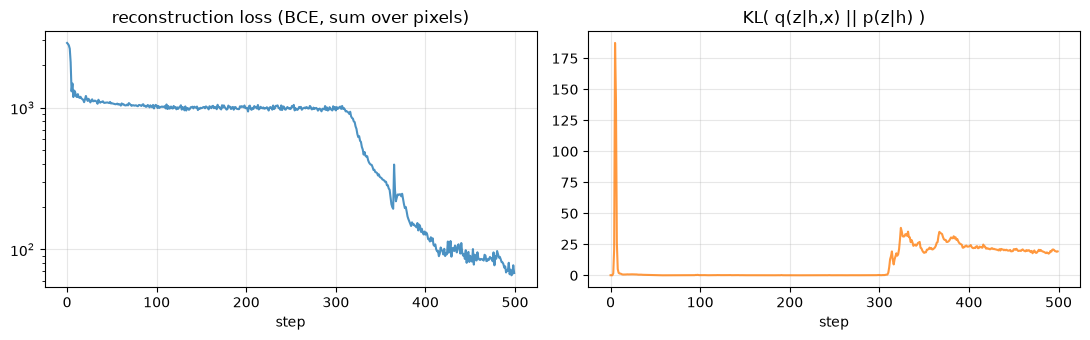

In [5]:
SEQ_LEN, BATCH, STEPS, BETA, LR = 12, 24, 500, 1.0, 3e-3

def sample_seq_batch(rng, batch=BATCH, seq_len=SEQ_LEN):
    """randomly sample `batch` contiguous clips of length seq_len"""
    ep = rng.integers(0, N_EP, batch)
    st = rng.integers(0, EP_LEN - seq_len, batch)
    idx = st[:, None] + np.arange(seq_len)[None, :]
    return frames_t[ep[:, None], idx], actions_t[ep[:, None], idx]

def train(model, steps, beta=BETA, log_every=150, seed=1):
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    tr = np.random.default_rng(seed)
    hist = []
    t0 = time.time()
    model.train()
    for step in range(steps):
        xs, ac = sample_seq_batch(tr)
        rec, kl, _, _ = model.observe(xs, ac)
        loss = rec + beta * kl
        opt.zero_grad()
        loss.backward()
        opt.step()
        hist.append((rec.item(), kl.item()))
        if (step + 1) % log_every == 0:
            print(f"step {step+1:4d}/{steps}  recon(sum-BCE) {rec.item():.1f}  KL {kl.item():.2f}")
    print(f"trained in {time.time() - t0:.1f}s on CPU")
    return np.array(hist)

hist = train(rssm, STEPS)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(hist[:, 0], color="tab:blue", alpha=0.8)
axes[0].set_yscale("log"); axes[0].set_xlabel("step")
axes[0].set_title("reconstruction loss (BCE, sum over pixels)")
axes[1].plot(hist[:, 1], color="tab:orange", alpha=0.8)
axes[1].set_xlabel("step"); axes[1].set_title("KL( q(z|h,x) || p(z|h) )")
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Visualize ① — Observation Reconstruction

**Why check reconstruction first:** If the model cannot even "reconstruct $x_t$ while looking at $x_t$", nothing else matters. Below we unroll one full episode along time: at each step the posterior sees the real frame and samples $z_t$, and the decoder reconstructs from $(h_t, z_t)$. A sharp ball means $(h_t, z_t)$ really encodes the ball's configuration.

episode 0: recon(sum-BCE) 62.0, mean KL per step 21.04


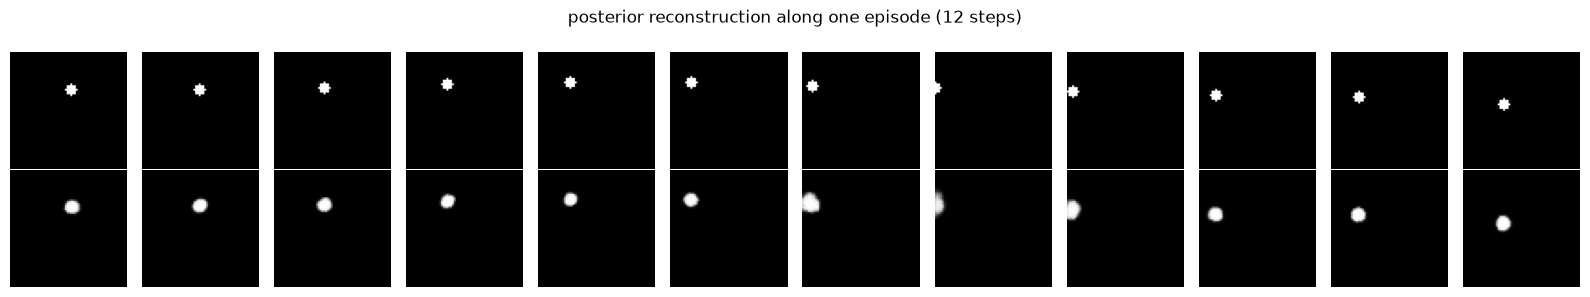

In [6]:
rssm.eval()
with torch.no_grad():
    ep_i = 0
    xs = frames_t[ep_i:ep_i + 1, :12]
    ac = actions_t[ep_i:ep_i + 1, :12]
    rec, kl, _, recons = rssm.observe(xs, ac)
print(f"episode {ep_i}: recon(sum-BCE) {rec.item():.1f}, mean KL per step {kl.item():.2f}")

fig, axes = plt.subplots(2, 12, figsize=(16, 3))
for j in range(12):
    axes[0, j].imshow(xs[0, j, 0], cmap="gray", vmin=0, vmax=1)
    axes[1, j].imshow(recons[0, j], cmap="gray", vmin=0, vmax=1)
    for ax in axes[:, j]:
        ax.axis("off")
axes[0, 0].set_ylabel("input $x_t$", fontsize=10)
axes[1, 0].set_ylabel("recon $\hat{x}_t$", fontsize=10)
plt.suptitle("posterior reconstruction along one episode (12 steps)")
plt.tight_layout()
plt.show()


## 6. Visualize ② — Prior vs Posterior

**Why compare them:** The prior is a "blind guess", the posterior has "seen the answer". The gap between them is the information the observation provides, which is exactly what the KL is shrinking. Expect to see: (a) the posterior std is generally smaller than the prior's (more certain after seeing the observation); (b) the distributions of their means have a similar shape but do not coincide; (c) the KL is unevenly spread across latent dimensions, with a few dimensions carrying most of the information.

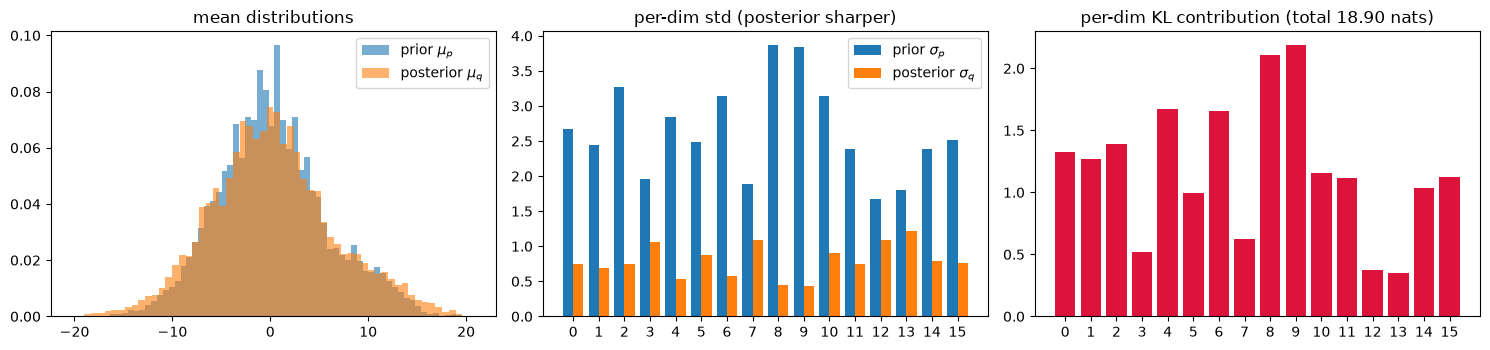

In [7]:
xs, ac = sample_seq_batch(np.random.default_rng(3), batch=64, seq_len=12)
with torch.no_grad():
    _, kl_now, stats, _ = rssm.observe(xs, ac)
mu_p = torch.cat([s[0] for s in stats]); std_p = torch.cat([s[1] for s in stats])
mu_q = torch.cat([s[2] for s in stats]); std_q = torch.cat([s[3] for s in stats])

# per-dim KL contribution (analytic, averaged over batch*time)
var_q, var_p = std_q ** 2, std_p ** 2
kl_per_dim = (torch.log(std_p / std_q) + (var_q + (mu_q - mu_p) ** 2) / (2 * var_p) - 0.5).mean(0)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].hist(mu_p.numpy().ravel(), bins=60, alpha=0.6, density=True, label="prior $\mu_p$")
axes[0].hist(mu_q.numpy().ravel(), bins=60, alpha=0.6, density=True, label="posterior $\mu_q$")
axes[0].legend(); axes[0].set_title("mean distributions")
dims = np.arange(Z_DIM)
axes[1].bar(dims - 0.2, std_p.mean(0), width=0.4, label="prior $\sigma_p$")
axes[1].bar(dims + 0.2, std_q.mean(0), width=0.4, label="posterior $\sigma_q$")
axes[1].set_xticks(dims); axes[1].legend(); axes[1].set_title("per-dim std (posterior sharper)")
axes[2].bar(dims, kl_per_dim.numpy(), color="crimson")
axes[2].set_xticks(dims); axes[2].set_title(f"per-dim KL contribution (total {kl_now.item():.2f} nats)")
plt.tight_layout()
plt.show()


## 7. Evaluate ① — One-Step Prediction

**Why:** This is the atomic operation of imagination: given the history $h_t$ (built during burn-in), sample $z_t$ from the prior **before seeing $x_t$** and decode it; the result should be close to the real $x_t$. It is the Kalman filter's predict step. The posterior reconstruction is plotted alongside for comparison. The prior version should be roughly right but slightly blurrier or offset, because it has not seen the current frame.

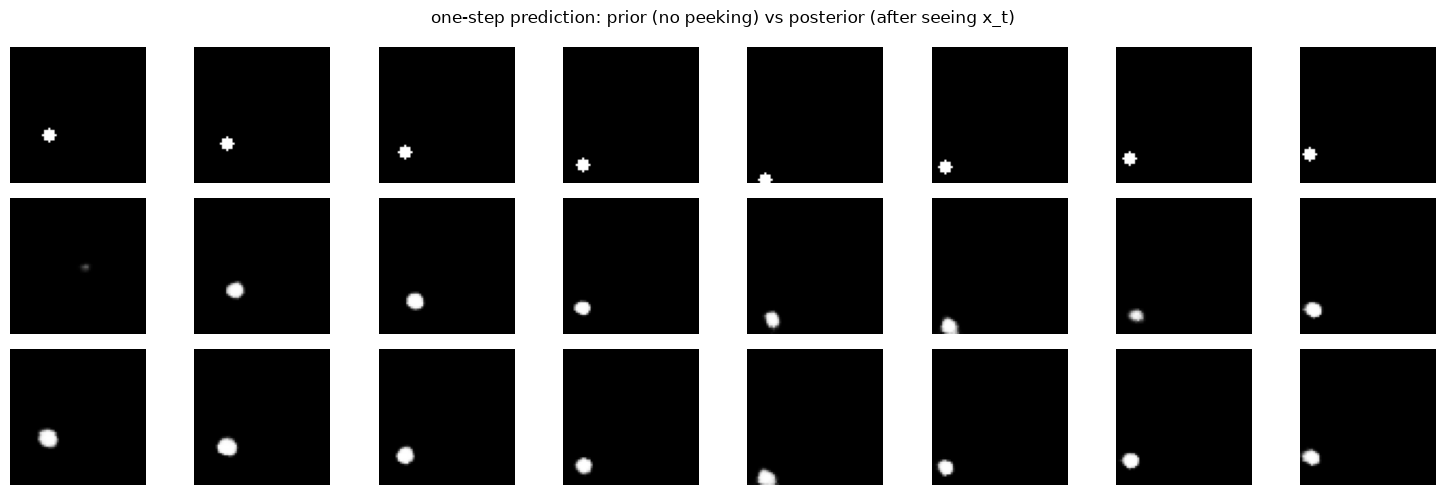

In [8]:
@torch.no_grad()
def one_step_predictions(model, xs, ac):
    """for each step t: first predict x_t with the prior (without seeing x_t), then reconstruct with the posterior (seeing x_t)"""
    B, T = xs.shape[:2]
    h = xs.new_zeros(B, H_DIM); z = xs.new_zeros(B, Z_DIM); a_prev = xs.new_zeros(B, A_DIM)
    prior_frames, post_frames = [], []
    for t in range(T):
        h = model.gru(torch.cat([z, a_prev], -1), h)
        mu_p, std_p = model.prior(h)
        z_prior = sample_gaussian(mu_p, std_p)
        prior_frames.append(torch.sigmoid(model.dec(h, z_prior))[0, 0])   # blind prediction
        mu_q, std_q = model.posterior(h, model.enc(xs[:, t]))
        z = sample_gaussian(mu_q, std_q)
        post_frames.append(torch.sigmoid(model.dec(h, z))[0, 0])          # reconstruct after seeing
        a_prev = ac[:, t]
    return prior_frames, post_frames

ep_i = 1
xs1 = frames_t[ep_i:ep_i + 1, :8]; ac1 = actions_t[ep_i:ep_i + 1, :8]
prior_f, post_f = one_step_predictions(rssm, xs1, ac1)

fig, axes = plt.subplots(3, 8, figsize=(15, 5))
for j in range(8):
    axes[0, j].imshow(xs1[0, j, 0], cmap="gray", vmin=0, vmax=1)
    axes[1, j].imshow(prior_f[j], cmap="gray", vmin=0, vmax=1)
    axes[2, j].imshow(post_f[j], cmap="gray", vmin=0, vmax=1)
    for ax in axes[:, j]:
        ax.axis("off")
axes[0, 0].set_ylabel("true $x_t$", fontsize=10)
axes[1, 0].set_ylabel("prior prediction", fontsize=10)
axes[2, 0].set_ylabel("posterior recon", fontsize=10)
plt.suptitle("one-step prediction: prior (no peeking) vs posterior (after seeing x_t)")
plt.tight_layout()
plt.show()


## 7. Evaluate ② — Multi-Step Imagination Rollout (prior only)

**Why this is the payoff:** Give the model 4 frames of history (burn-in, digested by the posterior), then **never give it another observation**. Give it only the future action sequence and let it imagine 15 frames open-loop in latent space:

$$h_{k+1} = \mathrm{GRU}([z_k, a_k], h_k), \qquad z_{k+1} \sim p_\theta(z_{k+1} \mid h_{k+1}), \qquad \hat{x}_{k+1} = \mathrm{dec}(h_{k+1}, z_{k+1})$$

**Why must imagination use the prior?** Because the posterior $q(z_t|h_t,x_t)$ takes $x_t$ as input, and future frames do not exist yet. This is the source of the RSSM's train/test asymmetry: during training the posterior acts as the "teacher" and the KL distills its knowledge into the prior; during imagination the prior works alone. The grid below puts imagination (bottom row) next to the ground truth (top row). Note that imagination **should not** match the ground truth pixel for pixel: the environment is stochastic and the ground truth is only one of many plausible futures. A good imagination is a **sharp ball moving plausibly**.

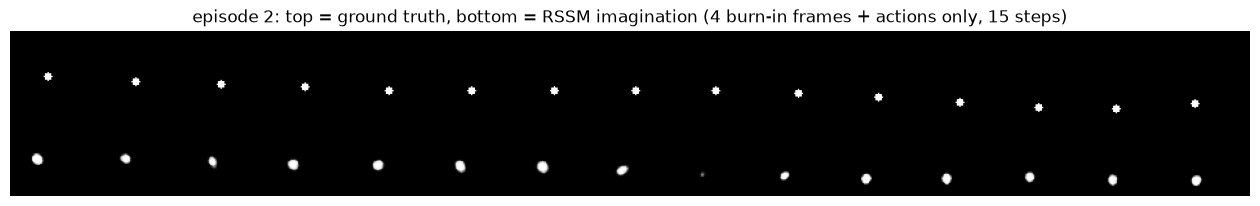

saved assets/imagination_grid.png and assets/imagination_rollout.gif


In [9]:
BURN, HORIZON = 4, 15
EP = 2
x_ctx = frames_t[EP:EP + 1, :BURN]
a_ctx = actions_t[EP:EP + 1, :BURN]
a_fut = actions_t[EP:EP + 1, BURN - 1:BURN - 1 + HORIZON]   # a_{BURN-1} drives the first imagined frame

imagined = rssm.imagine(x_ctx, a_ctx, a_fut)[0]              # (HORIZON, 64, 64)
gt = frames_np[EP, BURN:BURN + HORIZON]

grid = np.concatenate([np.concatenate(gt, axis=1), np.concatenate(imagined.numpy(), axis=1)], axis=0)
plt.figure(figsize=(16, 2.6))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.title(f"episode {EP}: top = ground truth, bottom = RSSM imagination (4 burn-in frames + actions only, 15 steps)")
plt.savefig("assets/imagination_grid.png", dpi=110, bbox_inches="tight")
plt.show()

side_by_side = [np.concatenate([g, d], axis=1) for g, d in zip(gt, imagined.numpy())]
imageio.mimsave("assets/imagination_rollout.gif",
                [(f * 255).astype(np.uint8) for f in side_by_side], duration=0.25)
print("saved assets/imagination_grid.png and assets/imagination_rollout.gif")


## 7. Evaluate ③ — Several dreams: one history, many futures

**Why:** This is the signature ability of the stochastic latent. Fix the same burn-in and actions, change only the sampling noise, and imagine 3 times. A deterministic model would output the same (blurry) sequence 3 times; the RSSM should give 3 trajectories that are **each sharp and different from one another**: a distribution over futures, not the average future.

mean pixel-wise std across 3 dreams: 0.011  (0 = deterministic model)


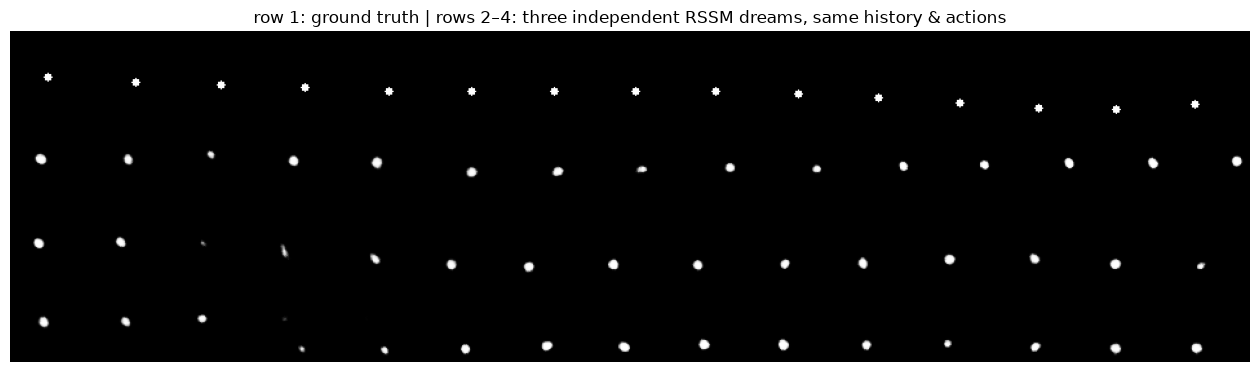

In [10]:
dreams = [rssm.imagine(x_ctx, a_ctx, a_fut)[0].numpy() for _ in range(3)]
stack = np.stack(dreams)                                     # (3, HORIZON, 64, 64)
pixel_std = stack.std(axis=0).mean()
print(f"mean pixel-wise std across 3 dreams: {pixel_std:.3f}  (0 = deterministic model)")

rows = [np.concatenate(gt, axis=1)] + [np.concatenate(d, axis=1) for d in dreams]
grid = np.concatenate(rows, axis=0)
plt.figure(figsize=(16, 5))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.title("row 1: ground truth | rows 2–4: three independent RSSM dreams, same history & actions")
plt.savefig("assets/multi_dreams.png", dpi=110, bbox_inches="tight")
plt.show()


## 8. Experiment: Deterministic-Only Baseline — why a pure RNN is not enough

Now we answer the first teaching question head-on. We train a baseline with **exactly the same structure**, the only difference being that the randomness is removed: $z_t$ is simply the posterior mean (no sampling), and the KL is replaced by an MSE so the prior network learns to predict it. This is a "deterministic RNN world model" (a GRU version of the Lab 2 model).

**Prediction:** The deterministic model has no randomness in its structure, so imagination can only output **one** trajectory. What it learns is some "average trajectory" over all possible futures: sharp and confident, but often off from any future that actually happens. The RSSM instead samples several individually plausible trajectories, and one of them is often close to the ground truth. Also: if you average several RSSM dreams in pixel space, you will see what the "conditional mean" really looks like, a blurry double image (exactly the phenomenon from Section 3.1).

step  150/320  recon(sum-BCE) 734.1  KL 50.29


step  300/320  recon(sum-BCE) 64.2  KL 132.33


trained in 61.7s on CPU


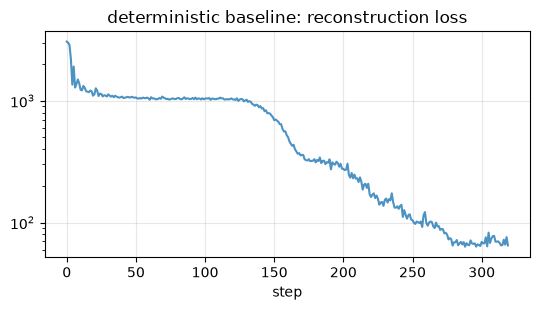

In [11]:
det = TinyRSSM(stochastic=False)     # same structure, no stochastic state
hist_det = train(det, steps=320)

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(hist_det[:, 0], color="tab:blue", alpha=0.8)
ax.set_yscale("log"); ax.set_xlabel("step")
ax.set_title("deterministic baseline: reconstruction loss")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


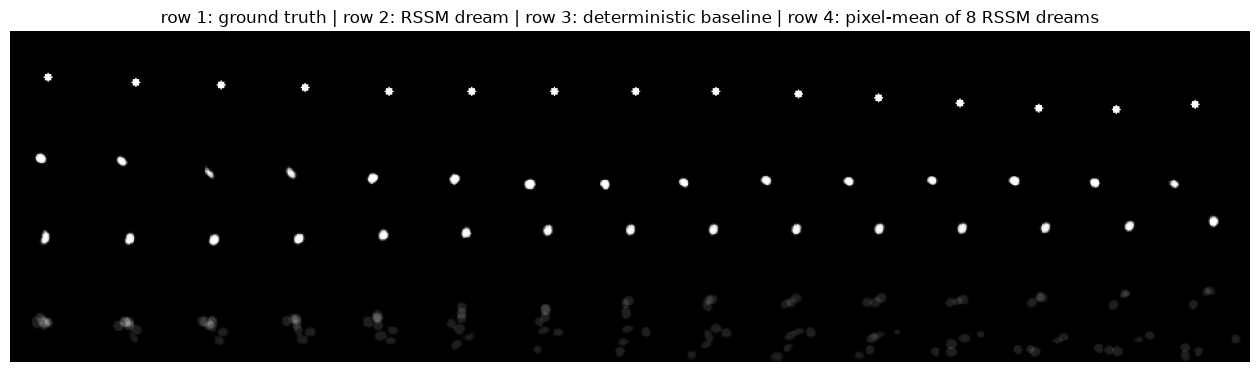

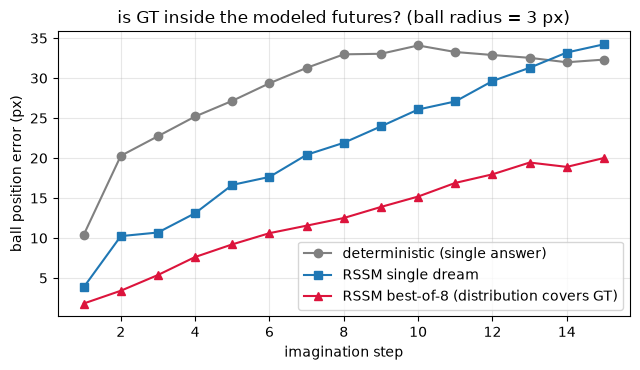

RSSM predicted position spread (px): step1 1.5 -> step15 10.7
deterministic spread: 0.0 (structurally cannot express uncertainty)
step 15 position error: det 32.3px | RSSM single 34.2px | RSSM best-of-8 20.0px


In [12]:
det_imagined = det.imagine(x_ctx, a_ctx, a_fut)[0].numpy()
rssm_imagined = rssm.imagine(x_ctx, a_ctx, a_fut)[0].numpy()
dreams8_ep = torch.stack([rssm.imagine(x_ctx, a_ctx, a_fut) for _ in range(8)])[:, 0].numpy()
mean_dream = dreams8_ep.mean(0)          # conditional mean in pixel space ≈ the optimum when only one frame may be predicted

rows = [np.concatenate(gt, axis=1),
        np.concatenate(rssm_imagined, axis=1),
        np.concatenate(det_imagined, axis=1),
        np.concatenate(mean_dream, axis=1)]
grid = np.concatenate(rows, axis=0)
plt.figure(figsize=(16, 5))
plt.imshow(grid, cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.title("row 1: ground truth | row 2: RSSM dream | row 3: deterministic baseline | row 4: pixel-mean of 8 RSSM dreams")
plt.savefig("assets/rssm_vs_deterministic.png", dpi=110, bbox_inches="tight")
plt.show()

# evaluate in batch over 32 episodes to avoid single-example luck
ev = np.random.default_rng(5)
eps_idx = ev.integers(0, N_EP, 32)
xc = frames_t[eps_idx, :BURN]; acx = actions_t[eps_idx, :BURN]
af = actions_t[eps_idx, BURN - 1:BURN - 1 + HORIZON]
gt_batch = frames_t[eps_idx, BURN:BURN + HORIZON, 0]                   # (32, H, 64, 64)
rssm_batch = rssm.imagine(xc, acx, af)
det_batch = det.imagine(xc, acx, af)
dreams8 = torch.stack([rssm.imagine(xc, acx, af) for _ in range(8)])   # (8, 32, H, 64, 64)

def ball_position(frames):
    """threshold -> center of mass, returns (..., 2) pixel coordinates"""
    w = (np.asarray(frames) > 0.5).astype(np.float32)
    yy, xx = np.mgrid[0:SIZE, 0:SIZE]
    tot = w.sum(axis=(-2, -1)) + 1e-8
    return np.stack([(w * xx).sum(axis=(-2, -1)) / tot,
                     (w * yy).sum(axis=(-2, -1)) / tot], axis=-1)

gt_pos = ball_position(gt_batch.numpy())                      # (32, H, 2)
det_pos = ball_position(det_batch.numpy())
dreams_pos = ball_position(dreams8.numpy())                   # (8, 32, H, 2)

det_err = np.linalg.norm(det_pos - gt_pos, axis=-1).mean(0)               # (H,)
rssm_err = np.linalg.norm(ball_position(rssm_batch.numpy()) - gt_pos, axis=-1).mean(0)
best_err = np.linalg.norm(dreams_pos - gt_pos, axis=-1).min(0).mean(0)    # best-of-8

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(range(1, HORIZON + 1), det_err, "o-", label="deterministic (single answer)", color="gray")
ax.plot(range(1, HORIZON + 1), rssm_err, "s-", label="RSSM single dream", color="tab:blue")
ax.plot(range(1, HORIZON + 1), best_err, "^-", label="RSSM best-of-8 (distribution covers GT)", color="crimson")
ax.set_xlabel("imagination step"); ax.set_ylabel("ball position error (px)")
ax.set_title("is GT inside the modeled futures? (ball radius = 3 px)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

spread = dreams_pos.std(axis=0).mean(axis=(0, 2))             # (H,) how far RSSM's predicted futures spread
print(f"RSSM predicted position spread (px): step1 {spread[0]:.1f} -> step15 {spread[-1]:.1f}")
print(f"deterministic spread: 0.0 (structurally cannot express uncertainty)")
print(f"step 15 position error: det {det_err[-1]:.1f}px | RSSM single {rssm_err[-1]:.1f}px | RSSM best-of-8 {best_err[-1]:.1f}px")

### 8.1 Analysis: answering the three questions

Putting the experimental evidence together:

1. **Why is a purely deterministic RNN not enough?** The environment itself is stochastic (Section 3.1: same state, same actions, different noise → different futures; after 10–15 steps the position uncertainty reaches ±10–15 px, while the ball's radius is only 3 px). The deterministic model has no randomness in its structure and can only commit to **one** trajectory. It converges to an "average trajectory": sharp and confident, but often not equal to any future that actually happens.
2. **Why do we need a stochastic latent state?** Both the deterministic model and a single RSSM sample drift away from the ground truth as the horizon grows, but the RSSM's best-of-8 is clearly closer: the ground truth lies inside the distribution the RSSM produces, and the position spread of its dreams grows with the horizon, which is exactly the growing uncertainty of the real world. The deterministic model's spread is structurally 0.
3. **Why train with the posterior and imagine with the prior?** Training needs a latent that has seen $x_t$ so reconstruction can succeed; imagination has no $x_t$ to see. The KL term bridges the two, which is why the prior alone can produce sharp, plausible multi-step dreams.

### ✏️ Exercise 1 — Latent dimension

Change `Z_DIM` to 4 and to 32 and retrain (change `rssm = TinyRSSM(z_dim=..., ...)` and rerun Sections 5–7). Observe: how do the total KL, reconstruction quality, and imagination sharpness change? What is the smallest dimension that is "good enough" for this task, and how does it relate to the intrinsic dimension of the world (position + velocity ≈ 4 dimensions)?

**Hint:** Too small a dimension sacrifices reconstruction first (the ball deforms); too large makes the KL term expensive and the prior harder to learn.

In [13]:
# YOUR CODE HERE
# hint: rssm4 = TinyRSSM(z_dim=4, stochastic=True); hist4 = train(rssm4, 400)
pass


### ✏️ Exercise 2 — KL weight β

Retrain the RSSM with `beta=0.0` (KL off) and `beta=10.0` (KL dominates) and compare: (a) the prior/posterior std plots from Section 6; (b) imagination quality. You should see two classic failure modes: with β=0 the posterior carries information freely, the prior falls behind, and imagination collapses; with β too large the posterior does not dare to move away from the prior (**posterior collapse**) and reconstructions get blurry.

**Hint:** `train(model, steps, beta=0.0)`; DreamerV3 uses tricks such as free bits and KL balancing to ease this trade-off.

In [14]:
# YOUR CODE HERE
# hint: rssm_b0 = TinyRSSM(stochastic=True); hist_b0 = train(rssm_b0, 400, beta=0.0)
pass


### ✏️ Exercise 3 — Sequence length & noise level

Pick one direction (or do both):

1. Change `SEQ_LEN` to 4 and to 18 and retrain: the shorter the training sequences, the weaker the long-range dependencies the GRU learns. What happens to long-horizon imagination?
2. Change `NOISE_STD` to 0 (back to a deterministic world), regenerate the data, and compare RSSM vs baseline: when the environment is not stochastic, does the stochastic latent still help? How does the KL change?

**Hint:** After changing `NOISE_STD` you need to rerun the data-generation cell in Section 3; check whether the deterministic baseline stops being blurry at `NOISE_STD=0`.

In [15]:
# YOUR CODE HERE
pass


## 9. Questions — Check Your Understanding

1. Why is the deterministic baseline's imagination blurry while the RSSM samples stay sharp? Explain using "conditional mean vs sampling".
2. Could we train with the prior only (never letting the posterior see $x_t$)? What would the reconstruction loss look like?
3. Why **can't** imagination use the posterior? What is missing from its inputs?
4. The KL term pulls the prior toward the posterior. Why not the other way round (forcing the posterior to accommodate the prior)?
5. What does the burn-in phase (the first steps of imagination) do? Without it, where would imagination start?

## 10. Takeaways

- In a few minutes on CPU you trained a **minimal RSSM** from scratch: `h_t = GRU(h_{t-1}, z_{t-1}, a_{t-1})` handles memory, `z_t ~ p(z_t|h_t)` handles uncertainty, the posterior $q(z_t|h_t,x_t)$ handles correction from observations, and the ELBO (recon + β·KL) handles training. All the core logic (GRU cell, Gaussian sampling, reparameterization, closed-form KL) is visible PyTorch code.
- **The blurry average of the deterministic-only baseline** is not a bug but a mathematical necessity: in a stochastic world, the optimum of a point-estimate model is the conditional mean. The stochastic latent replaces "averaging" with "sampling" and gives futures that are sharp and diverse.
- **The posterior-for-training / prior-for-imagination** asymmetry is bridged by the KL; this is the training paradigm that runs from PlaNet all the way to DreamerV3.
- Next (Lab 4): plan inside this learned world model by evaluating candidate action sequences in imagination (MPC/CEM) without touching the real environment.

**Related modules:** [Scientist 06 · RSSM](https://overdued.github.io/world-model-spatial-intelligence-course/en/docs/scientist/06-rssm) · [Scientist 05 · Latent Dynamics](https://overdued.github.io/world-model-spatial-intelligence-course/en/docs/scientist/05-latent-dynamics)

**Related papers:** Hafner et al. (2019), *PlaNet / RSSM* ([arXiv:1811.04551](https://arxiv.org/abs/1811.04551)); Hafner et al. (2020), *Dreamer* ([arXiv:1912.01603](https://arxiv.org/abs/1912.01603)); Hafner et al. (2021), *DreamerV2* ([arXiv:2010.02193](https://arxiv.org/abs/2010.02193)).